In [2]:
import numpy as np
import jax
import jax.numpy as jnp
from petra.posterior_chain import PosteriorChain
from petra.make_catalog import make_catalog_mv_normal
from flowjax.distributions import Transformed
from petra.samples_io import load_samples
import matplotlib.pyplot as plt
from petra.utils import make_uniform_prior
import json

from petra.copula_flows import make_catalog_copula_flows

jax.config.update('jax_enable_x64', True)

%load_ext autoreload
%autoreload 2

In [2]:
with open('/Users/aaron/Documents/nanograv/forks/petra_catalogs/example_notebooks/two_sinusoid/two_sine_results/cold_chains/sine_realization_0/chain_0.txt', 'r') as f:
    chain = np.loadtxt(f)[5000:,:-4]
with open('/Users/aaron/Documents/nanograv/forks/petra_catalogs/example_notebooks/two_sinusoid/two_sine_results/answers/sine_realization_0.json', 'r') as f:
    true_params = json.load(f)

In [3]:
posterior_chain = load_samples('/Users/aaron/Documents/lisa/catalogs_old/catalogs/simulations/run_without_noise_2bins/chains_SNR=7', num_params_per_source=8, thin=10, remove_low_numbers=True)

In [7]:
for i in range(posterior_chain.num_sources):
    np.savetxt(f'catalog_source_{i}.txt', posterior_chain.chain[:, i, :])

In [3]:
posterior_chain.shape

(2000, 13, 8)

(0.005, 0.0050025)

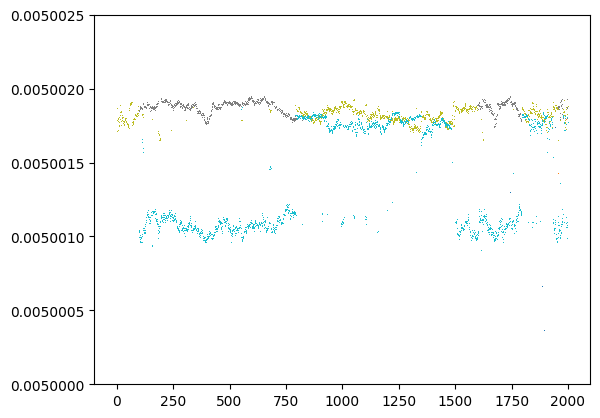

In [4]:
for i in range(13):
    plt.plot(posterior_chain[::1, i, 0], ',')
plt.ylim(0.005000, 0.0050025)

In [5]:
# posterior_chain = PosteriorChain.read_feather('./data/lisa_example.feather')

In [74]:
# posterior_chain = PosteriorChain(chain, num_sources=2, num_params_per_source=3)
relabeled_chain = make_catalog_mv_normal(posterior_chain, posterior_chain.num_sources, initialization_param_index=0)
# relabeled_chain = make_catalog_adaptive_gmm(posterior_chain, posterior_chain.num_sources, num_iterations=50)

Initializing with univariate normal distribution.

Sorting the posterior chain:
	Maximum number of iterations: 200
	Maximum number of source labels: 13



100%|██████████| 2000/2000 [00:00<00:00, 47884.28it/s]


Iteration 1: Difference in cost of assignment is -99.53246913700987 with total cost of -99.53246913700987.
	Probabilities in model: [0.99   0.941  0.99   0.1825 0.99   0.99   0.99   0.99   0.034  0.021
 0.99   0.99   0.99  ]


100%|██████████| 2000/2000 [00:00<00:00, 60692.46it/s]


Iteration 2: Difference in cost of assignment is -47.81506360409078 with total cost of -147.34753274110065.
	Probabilities in model: [0.99   0.9415 0.99   0.1985 0.99   0.99   0.99   0.99   0.0205 0.019
 0.99   0.99   0.99  ]


...

Iteration 5: Difference in cost of assignment is -5.204775288802921e-05 with total cost of -1045.851055593611.
	Probabilities in model: [0.98   0.9375 0.99   0.2    0.99   0.024  0.99   0.99   0.99   0.0375
 0.99   0.99   0.99  ]


100%|██████████| 2000/2000 [00:00<00:00, 18281.37it/s]


Iteration 6: Difference in cost of assignment is -9.11088473003474e-05 with total cost of -1045.8511467024582.
	Probabilities in model: [0.98   0.9375 0.99   0.2    0.99   0.024  0.99   0.99   0.99   0.0375
 0.99   0.99   0.99  ]


100%|██████████| 2000/2000 [00:00<00:00, 18619.92it/s]

Iteration 7: Difference in cost of assignment is 0.0 with total cost of -1045.8511467024582.
	Probabilities in model: [0.98   0.9375 0.99   0.2    0.99   0.024  0.99   0.99   0.99   0.0375
 0.99   0.99   0.99  ]
Stopped after 7 iterations because the cost didn't change from the previous iteration.


In [ ]:
import numpy as np

import matplotlib.pyplot as plt

# Get chain arrays from the PosteriorChain objects
chain1 = relabeled_chain.chain  # shape: (nsamples, n_sources, n_params)
chain2 = relabeled_new_chain.chain

nsamples, n_sources, n_params = chain1.shape

fig, axes = plt.subplots(n_params, 2, figsize=(12, 2 * n_params), sharex=True)

for i in range(n_params):
    ax_left = axes[i, 0]
    ax_right = axes[i, 1]
    
    # Plot all sources for parameter i from relabeled_chain
    for j in range(n_sources):
        ax_left.plot(np.arange(nsamples), chain1[:, j, i], '.', markersize=1, alpha=0.5)
    ax_left.set_ylabel(f'Param {i}')
    if i == 0:
        ax_left.set_title('Gaussian')
    
    # Plot all sources for parameter i from relabeled_new_chain
    for j in range(n_sources):
        ax_right.plot(np.arange(nsamples), chain2[:, j, i], '.', markersize=1, alpha=0.5)
    if i == 0:
        ax_right.set_title('Copula Flows')

axes[0, 0].set_ylim([0.004996, 0.00501])
axes[0, 1].set_ylim([0.004996, 0.00501])

axes[-1, 0].set_xlabel('Sample index')
axes[-1, 1].set_xlabel('Sample index')
plt.tight_layout()
plt.show()

In [5]:
# relabeled_new_chain = make_catalog_copula_flows(relabeled_chain, relabeled_chain.num_sources, num_iterations=50, plot_flows=True)
relabeled_chain_nf = make_catalog_copula_flows(posterior_chain, posterior_chain.num_sources, num_iterations=1)
# relabeled_new_chain = make_catalog_standardized_flows(posterior_chain, posterior_chain.num_sources, num_iterations=50)

Relabeling with Gaussian copula marginals + normalizing flows.

Sorting the posterior chain:
	Maximum number of iterations: 1
	Maximum number of source labels: 13



 19%|█▊        | 149/800 [00:03<00:15, 43.35it/s, train=10.4, val=13.4 (Max patience reached)] 


Iteration 1: Difference in cost of assignment is 8469998761.257376 with total cost of 8469998761.257376.
	Probabilities in model: [0.999999 0.999999 0.999999 0.999999 0.9985   0.999999 0.999999 0.9995
 0.999999 0.939    0.216    0.0225   0.003   ]
Final cost of assignment: 8469998761.257376 after the maximum number (1) of iterations.


In [44]:
relabeled_chain_nf = make_catalog_copula_flows(posterior_chain, posterior_chain.num_sources, num_iterations=50, checkpoint_dir='./checkpoints')

Relabeling with Gaussian copula marginals + normalizing flows.

Sorting the posterior chain:
	Maximum number of iterations: 50
	Maximum number of source labels: 13



 19%|█▊        | 149/800 [00:03<00:15, 41.62it/s, train=10.4, val=13.4 (Max patience reached)] 


Iteration 1: Difference in cost of assignment is 8469998761.257376 with total cost of 8469998761.257376.
	Probabilities in model: [0.999999 0.999999 0.999999 0.999999 0.9985   0.999999 0.999999 0.9995
 0.999999 0.939    0.216    0.0225   0.003   ]


/Users/aaron/miniconda3/envs/petra/lib/python3.11/site-packages/pyarrow/feather.py:156: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = Table.from_pandas(df, preserve_index=preserve_index)


  Checkpoint saved: ./checkpoints/posterior_chain_iteration_001.feather


...

Iteration 48: Difference in cost of assignment is -0.4006824493408203 with total cost of 8469998759.889977.
	Probabilities in model: [0.9995 0.998  0.979  0.999  0.9915 0.9695 0.983  0.978  0.991  0.877
 0.3875 0.0225 0.003 ]
  Checkpoint saved: ./checkpoints/posterior_chain_iteration_048.feather


 13%|█▎        | 102/800 [00:03<00:26, 26.37it/s, train=10.1, val=11.6 (Max patience reached)]
/Users/aaron/miniconda3/envs/petra/lib/python3.11/site-packages/pyarrow/feather.py:156: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = Table.from_pandas(df, preserve_index=preserve_index)


Iteration 49: Difference in cost of assignment is 0.2909212112426758 with total cost of 8469998760.180899.
	Probabilities in model: [0.9995 0.998  0.978  0.999  0.992  0.968  0.983  0.9775 0.991  0.8785
 0.3885 0.0225 0.003 ]
  Checkpoint saved: ./checkpoints/posterior_chain_iteration_049.feather


 12%|█▏        | 96/800 [00:04<00:29, 23.90it/s, train=10, val=11.8 (Max patience reached)]
/Users/aaron/miniconda3/envs/petra/lib/python3.11/site-packages/pyarrow/feather.py:156: UserWarning: The DataFrame has column names of mixed type. They will be converted to strings and not roundtrip correctly.
  table = Table.from_pandas(df, preserve_index=preserve_index)


Iteration 50: Difference in cost of assignment is 0.1655559539794922 with total cost of 8469998760.346455.
	Probabilities in model: [0.9995 0.998  0.98   0.9995 0.991  0.9665 0.9825 0.977  0.991  0.8765
 0.3915 0.0225 0.003 ]
  Checkpoint saved: ./checkpoints/posterior_chain_iteration_050.feather
Final cost of assignment: 8469998760.346455 after the maximum number (50) of iterations.


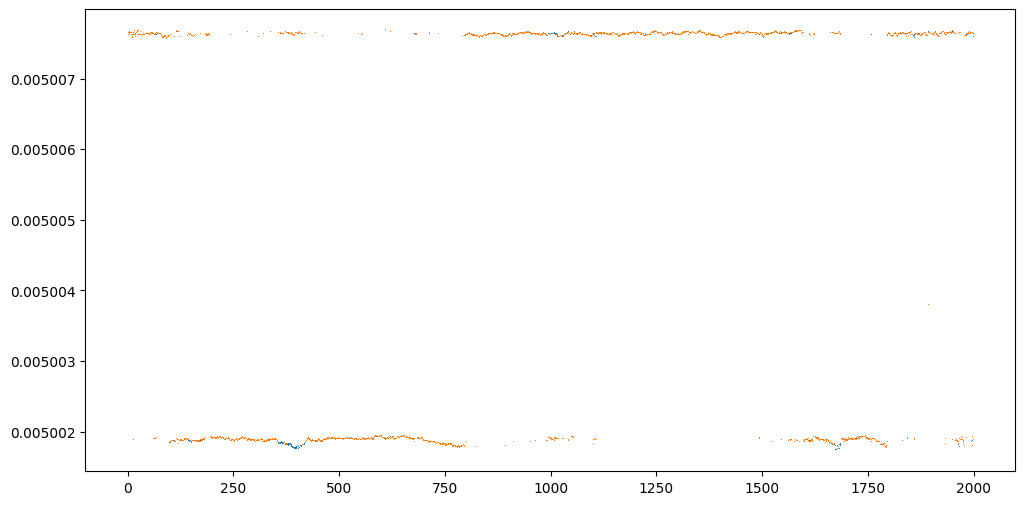

In [16]:
source_index = 7
plt.figure(figsize=(12, 6))
plt.plot(posterior_chain.chain[:,source_index,0], ',')
plt.plot(relabeled_chain_nf.chain[:,source_index,0], ',')

(0.005, 0.0050175)

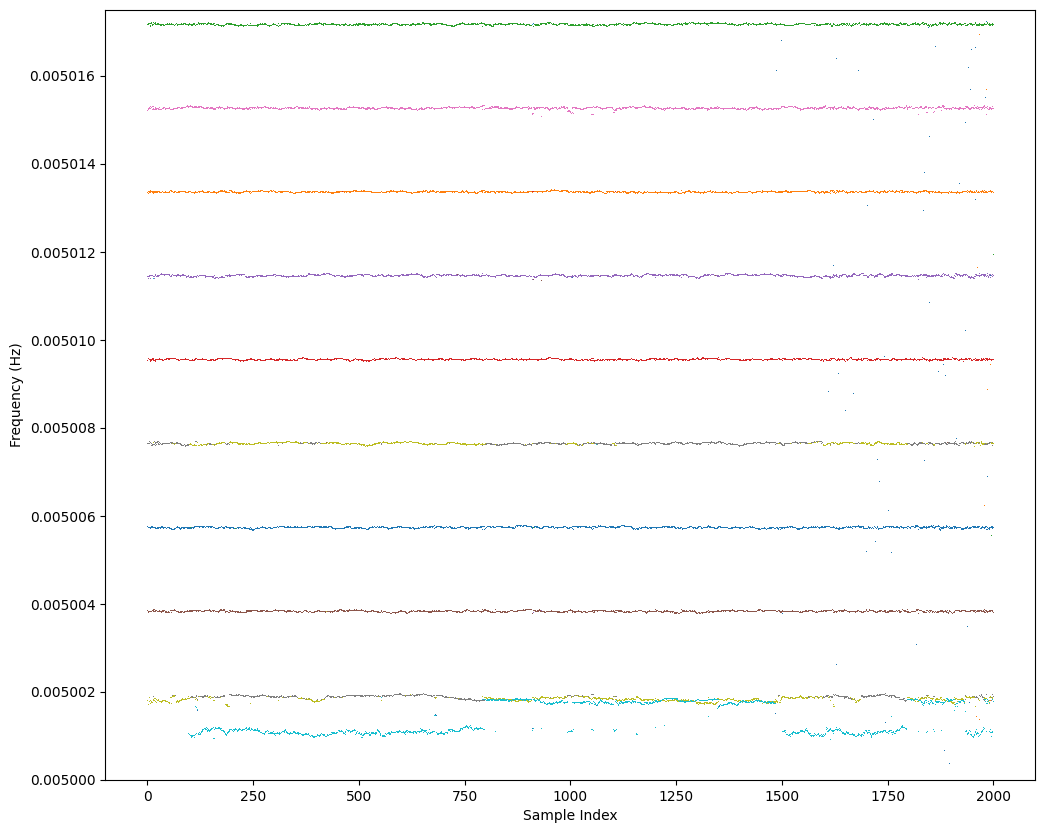

In [26]:
plt.figure(figsize=(12,10))
for source_index in range(13):
    plt.plot(relabeled_chain_nf.chain[:,source_index,0], ',')
plt.xlabel('Sample Index')
plt.ylabel('Frequency (Hz)')

plt.ylim(0.005000, 0.0050175)

(0.005, 0.0050175)

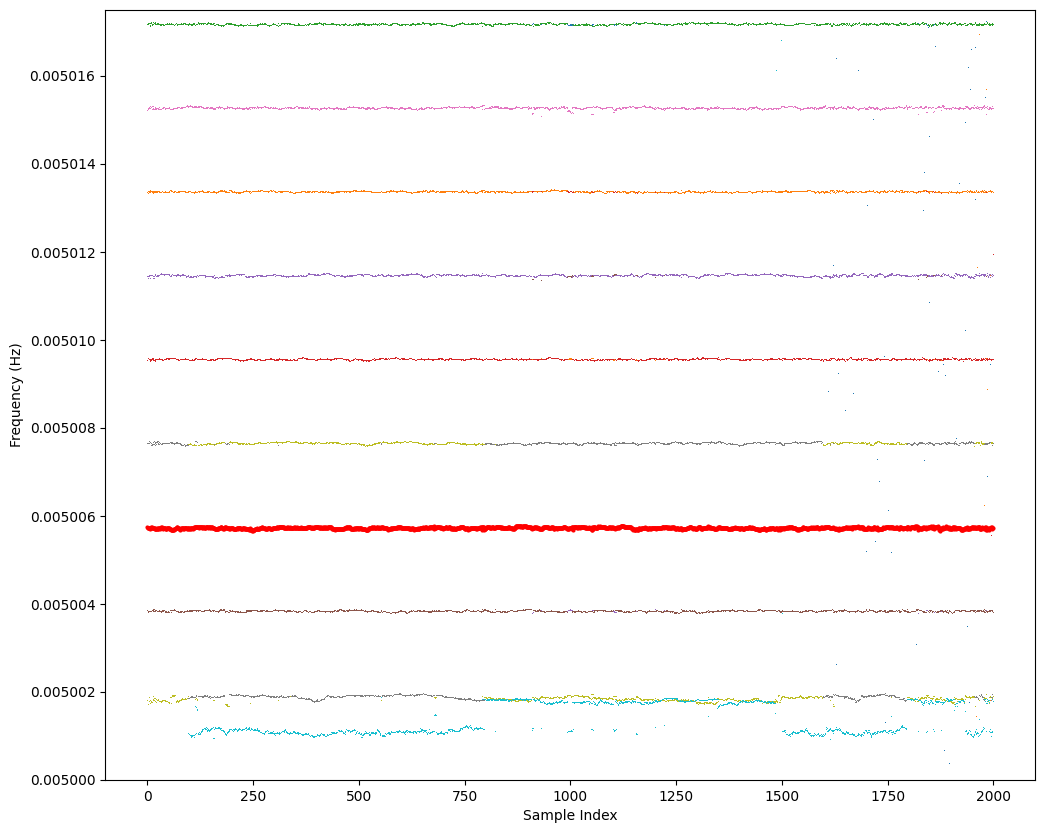

In [55]:
plt.figure(figsize=(12,10))
for source_index in range(13):
    plt.plot(posterior_chain.chain[:, source_index, 0], ',')
plt.plot(posterior_chain.chain[:, source_index, 0], ',')
plt.xlabel('Sample Index')
plt.ylabel('Frequency (Hz)')

plt.plot(relabeled_chain_nf[:, 0, 0], 'o', color='r', markersize=2)

plt.ylim(0.005000, 0.0050175)

### Unsorted samples

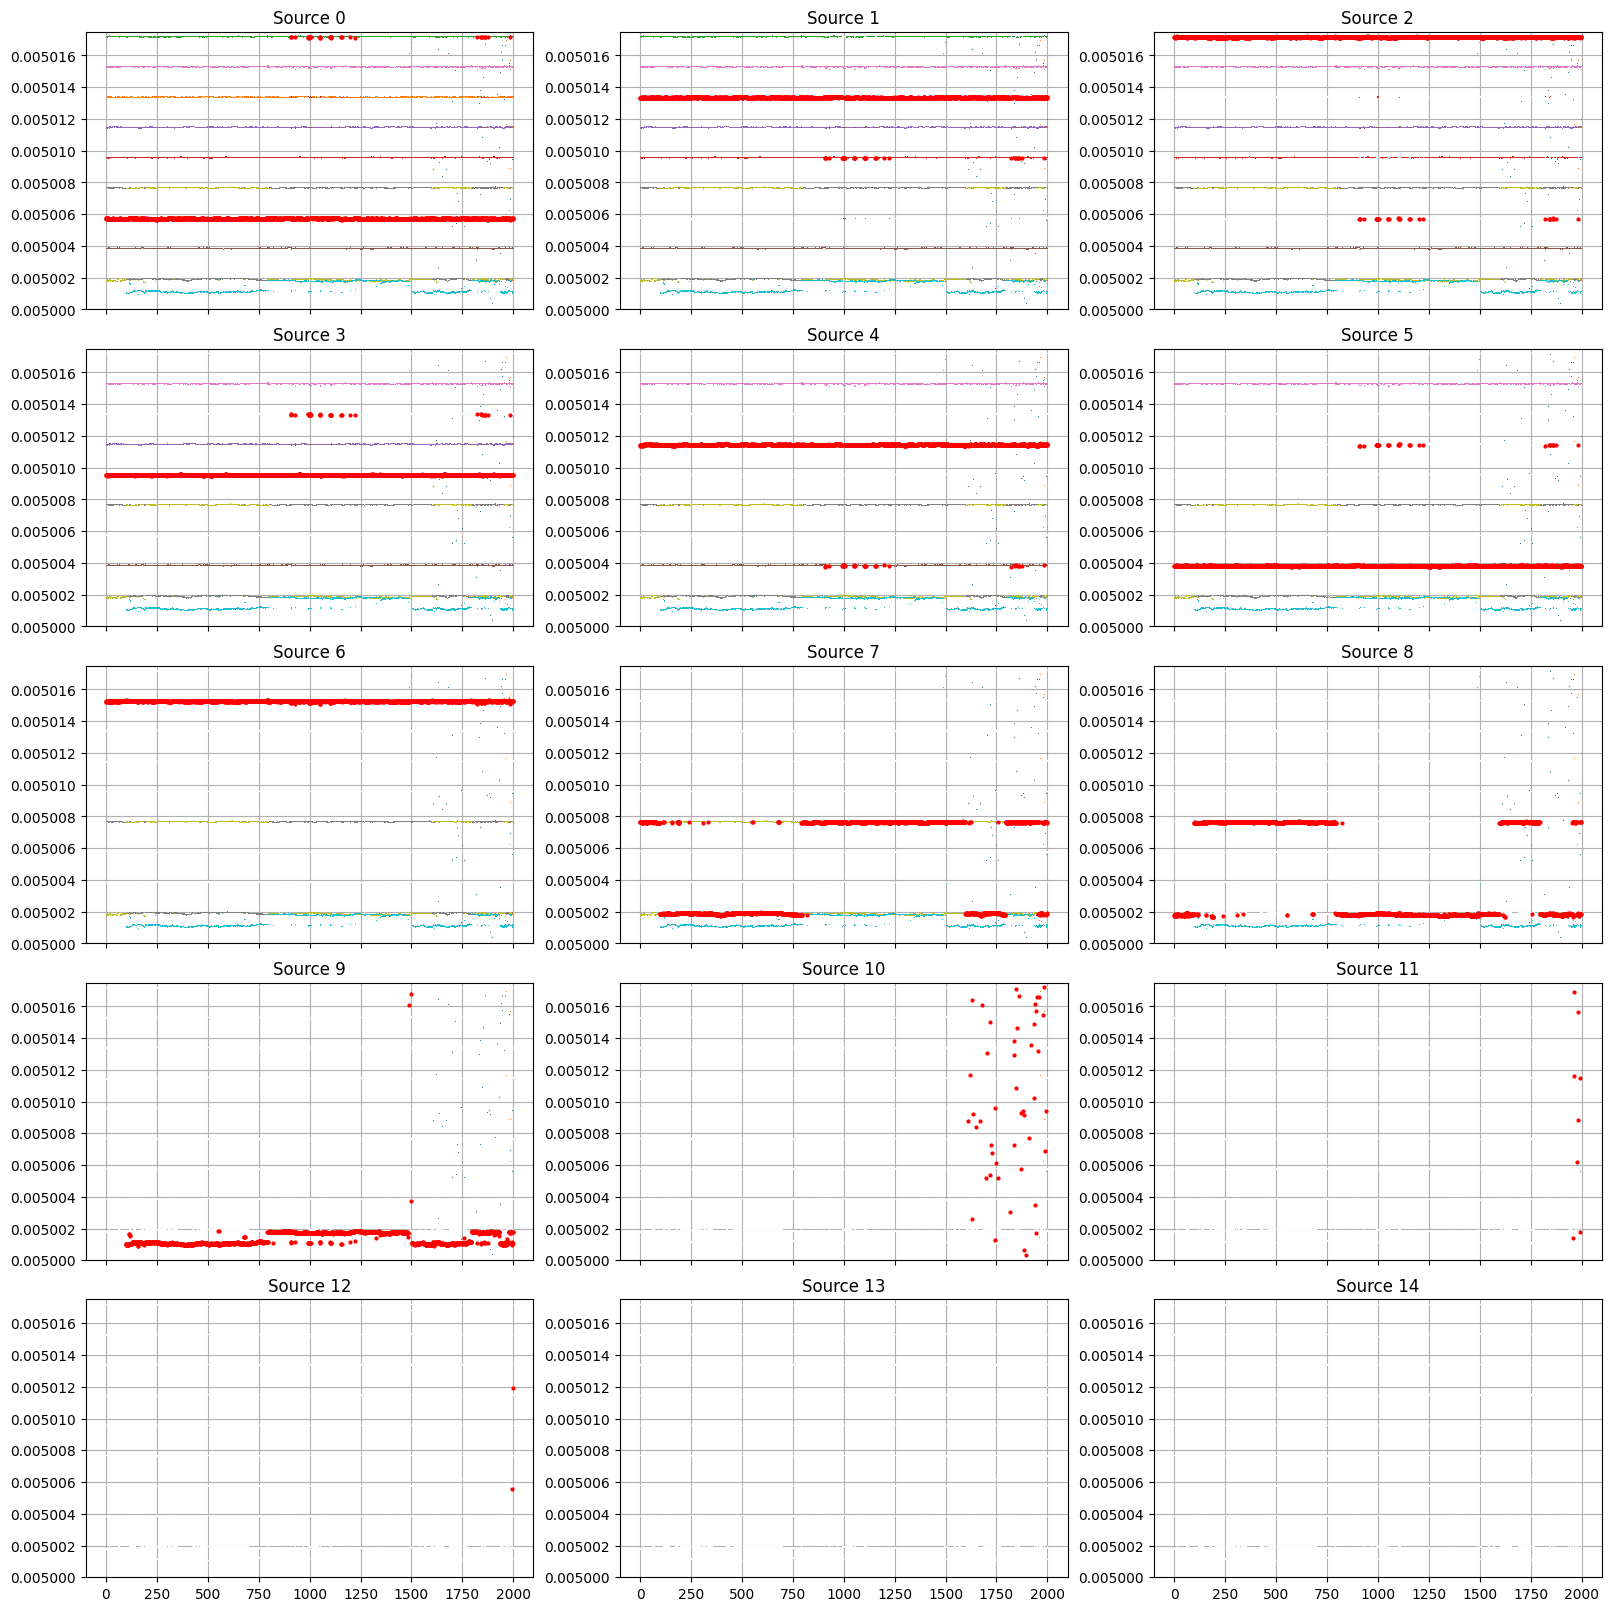

In [72]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 3, figsize=(16, 16), constrained_layout=True, sharex=True)  # add sharex/sharey if needed

for i in range(len(axes.flat)):
    ax = axes.flat[i]
    for source_index in range(13):
        ax.plot(posterior_chain.chain[:, source_index, 0], ',')
    for source_index in range(i):
        try:
            ax.plot(posterior_chain.chain[:, source_index, 0], ',', color='w')
        except IndexError:
            pass
    try:
        ax.plot(posterior_chain.chain[:, i, 0], 'o', color='r', markersize=2)
    except IndexError:
        pass
    ax.set_title(f"Source {i}")
    ax.set_ylim([0.005000, 0.0050175])
    ax.grid(True)

plt.savefig('./unsorted.png', bbox_inches='tight')
plt.show()

### Sorted samples

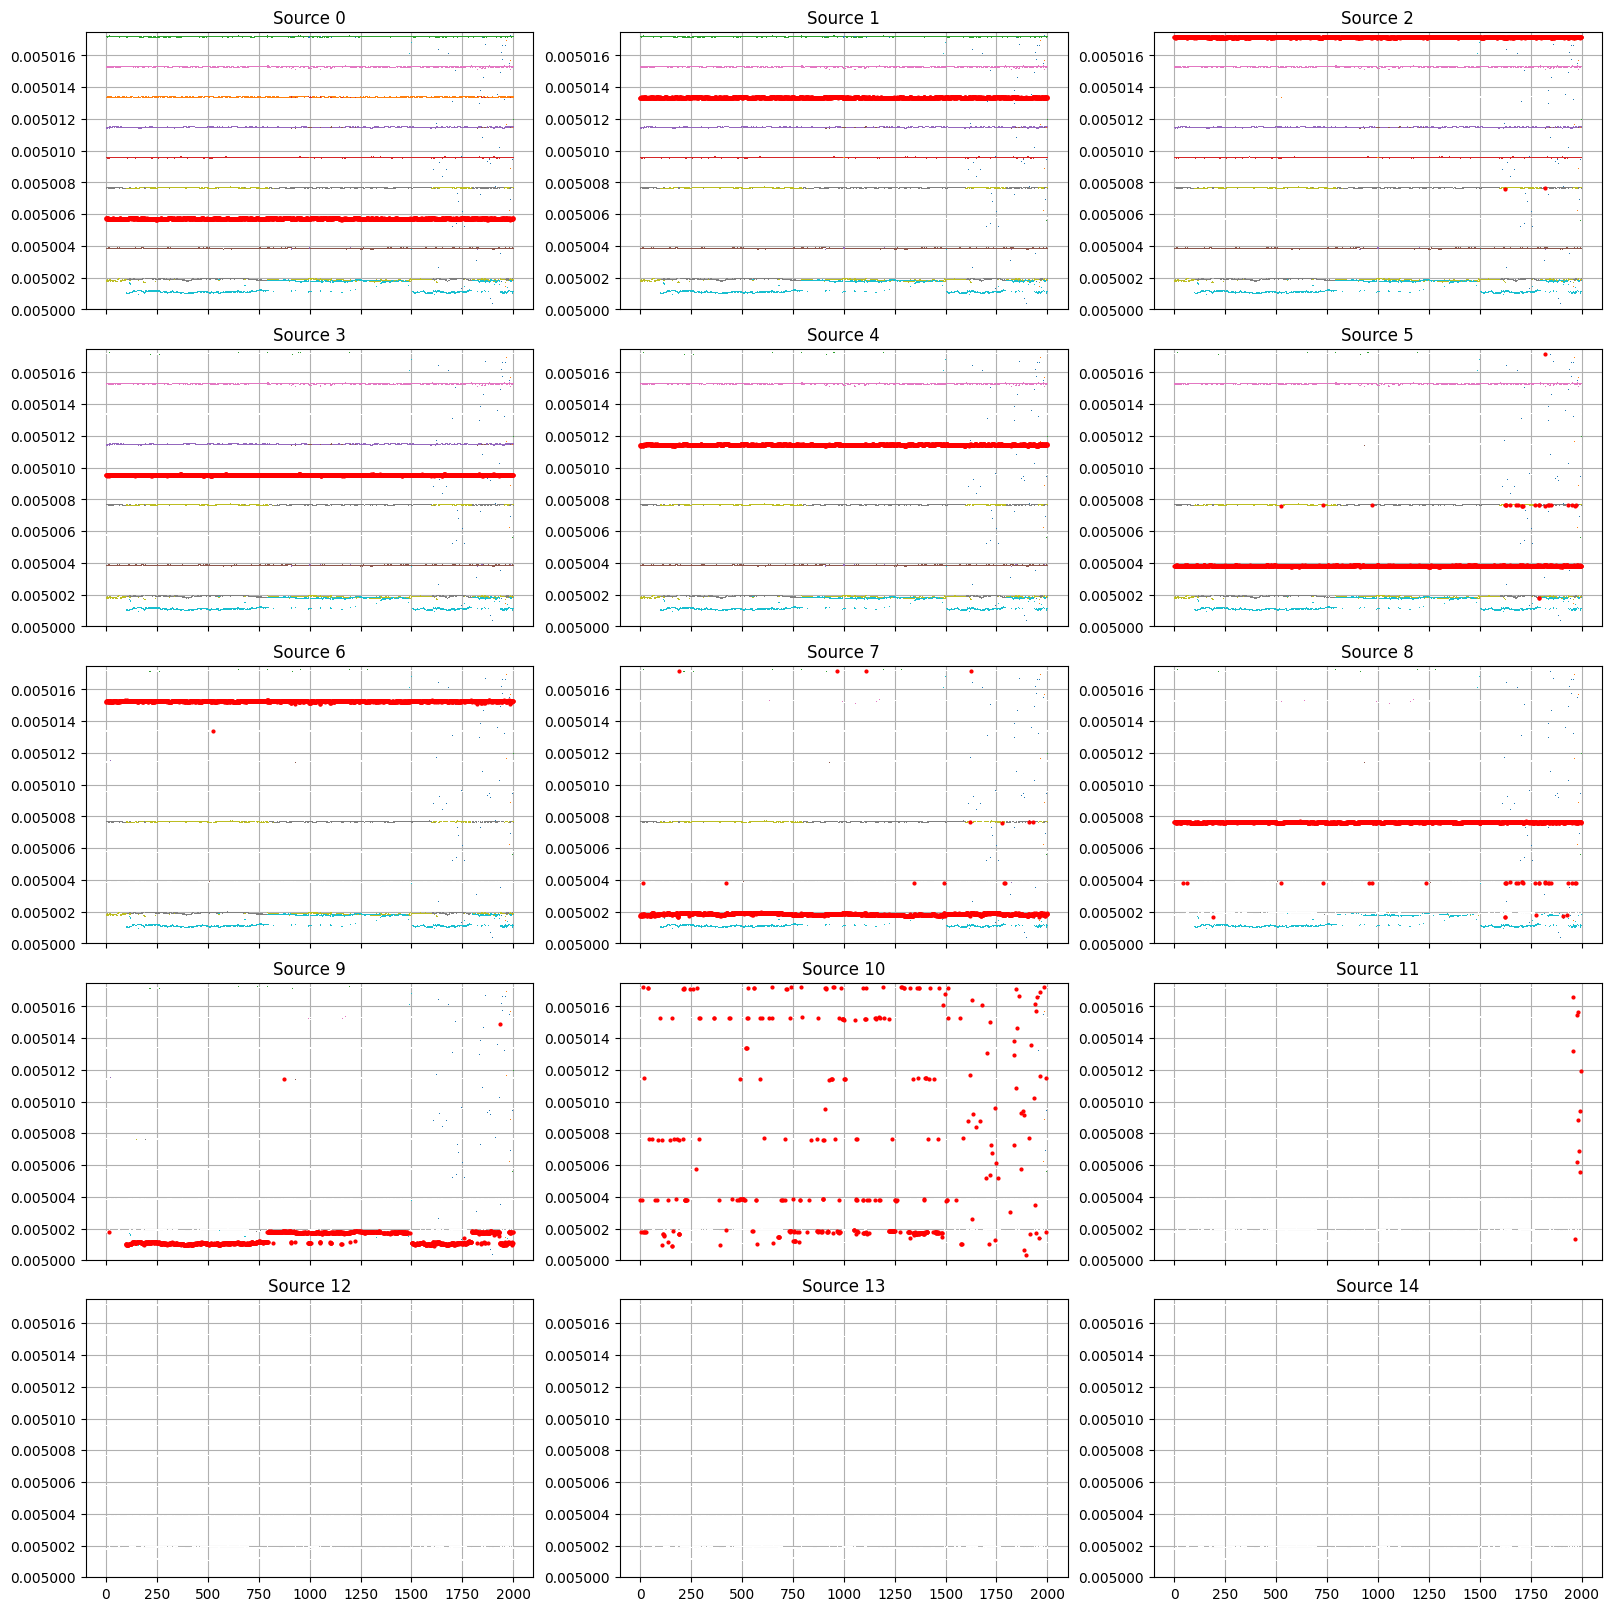

In [73]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 3, figsize=(16, 16), constrained_layout=True, sharex=True)  # add sharex/sharey if needed

for i in range(len(axes.flat)):
    ax = axes.flat[i]
    for source_index in range(13):
        ax.plot(posterior_chain.chain[:, source_index, 0], ',')
    for source_index in range(i):
        try:
            ax.plot(relabeled_chain_nf[:, source_index, 0], ',', color='w')
        except IndexError:
            pass
    try:
        ax.plot(relabeled_chain_nf[:, i, 0], 'o', color='r', markersize=2)
    except IndexError:
        pass
    ax.set_title(f"Source {i}")
    ax.set_ylim([0.005000, 0.0050175])
    ax.grid(True)

plt.savefig('./sorted.png', bbox_inches='tight')
plt.show()

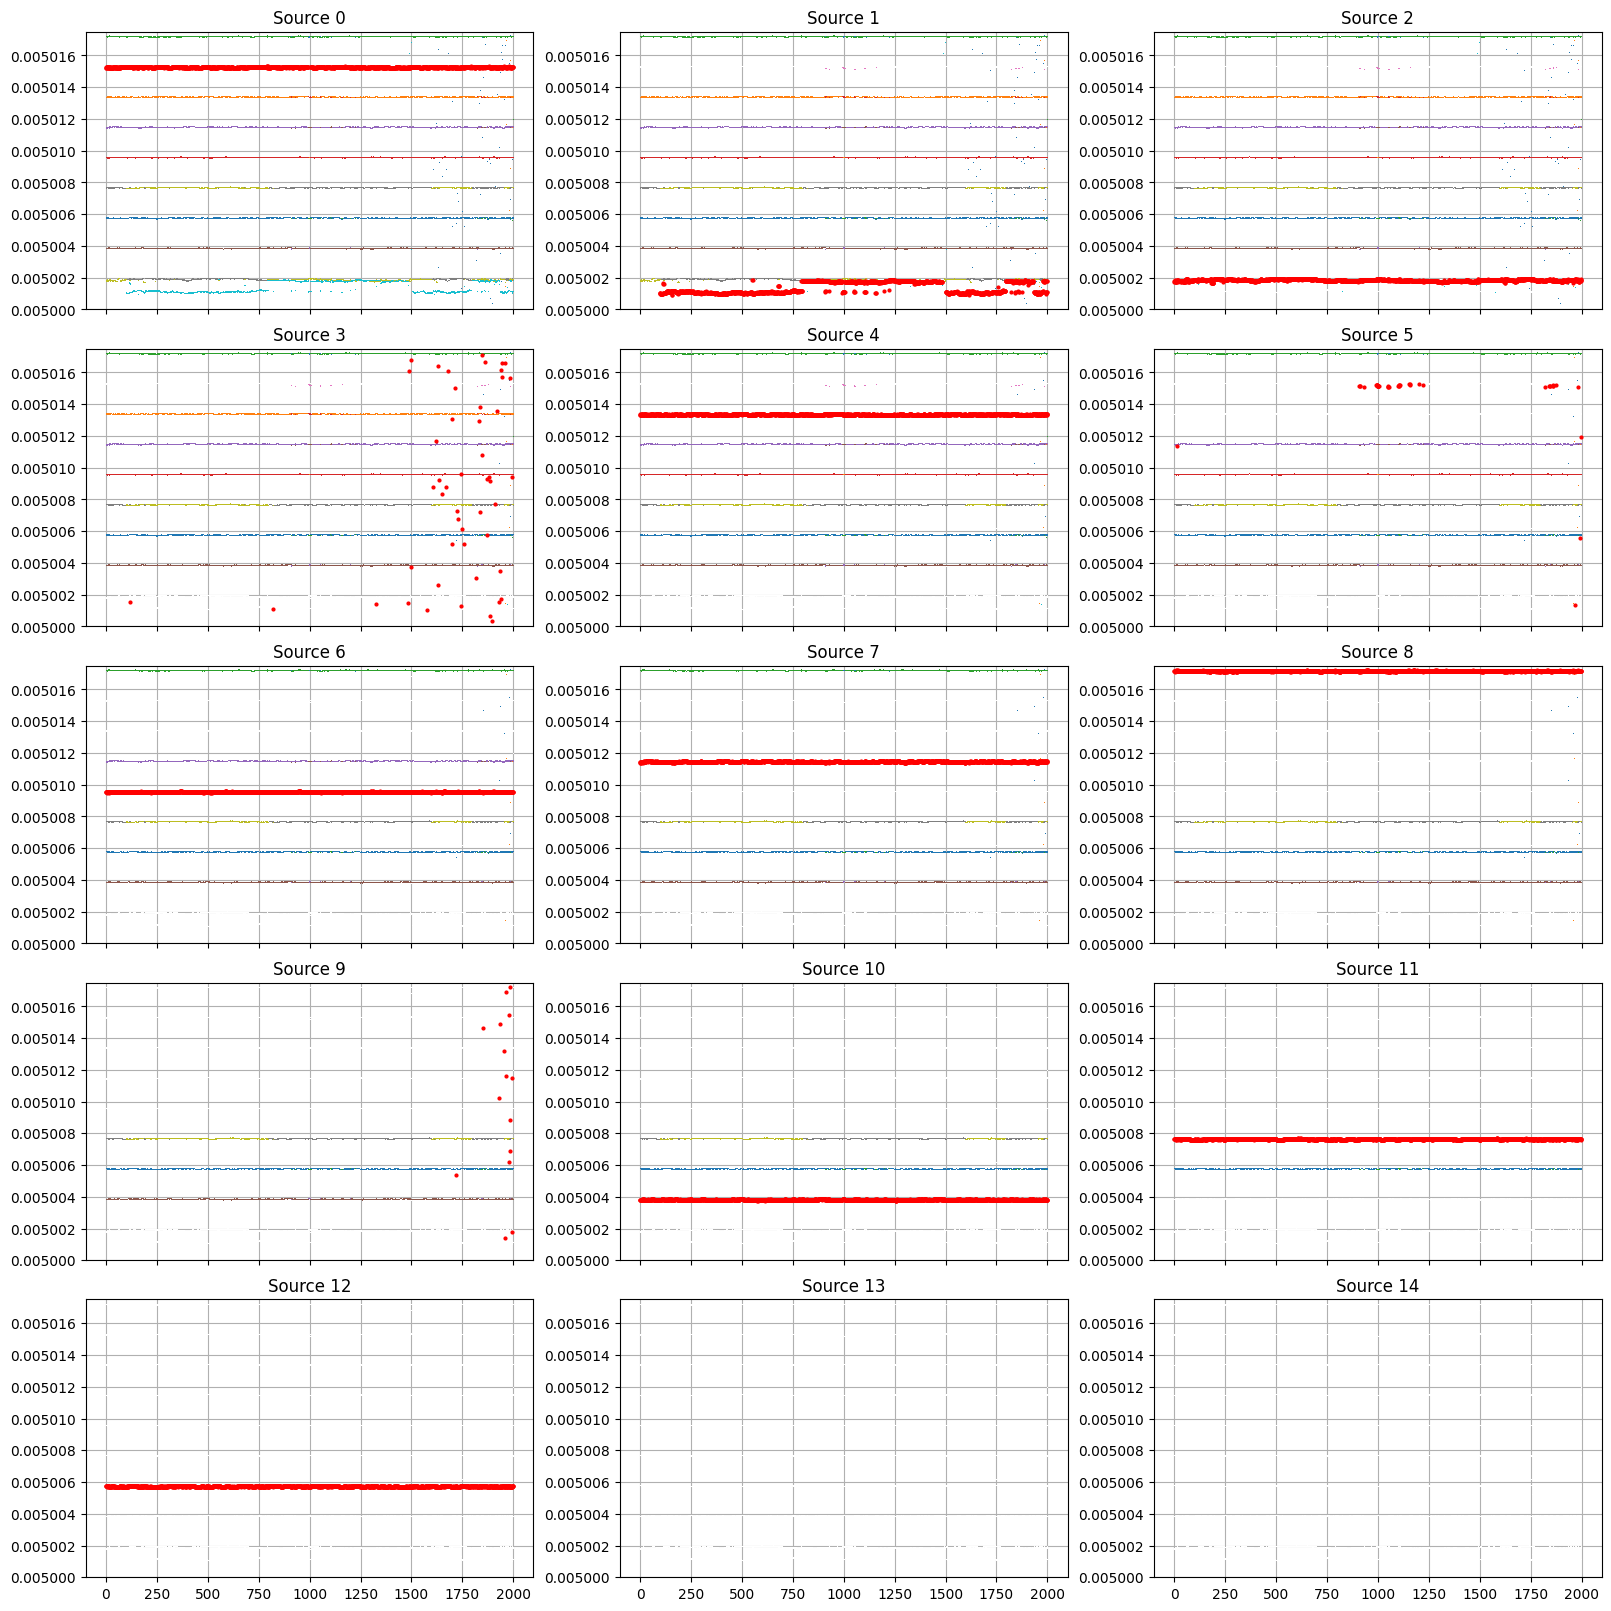

In [75]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 3, figsize=(16, 16), constrained_layout=True, sharex=True)  # add sharex/sharey if needed

for i in range(len(axes.flat)):
    ax = axes.flat[i]
    for source_index in range(13):
        ax.plot(posterior_chain.chain[:, source_index, 0], ',')
    for source_index in range(i):
        try:
            ax.plot(relabeled_chain.chain[:, source_index, 0], ',', color='w')
        except IndexError:
            pass
    try:
        ax.plot(relabeled_chain.chain[:, i, 0], 'o', color='r', markersize=2)
    except IndexError:
        pass
    ax.set_title(f"Source {i}")
    ax.set_ylim([0.005000, 0.0050175])
    ax.grid(True)

plt.savefig('./unsorted.png', bbox_inches='tight')
plt.show()

In [ ]:
# fit the 1D frequency samples only

In [ ]:
plt.figure(figsize=(12,10))
for source_index in range(13):
    plt.plot(relabeled_chain_nf.chain[:, source_index, 0], ',')
plt.plot(relabeled_chain_nf.chain[:, source_index, 0], ',')
plt.xlabel('Sample Index')
plt.ylabel('Frequency (Hz)')

plt.ylim(0.005000, 0.00502)

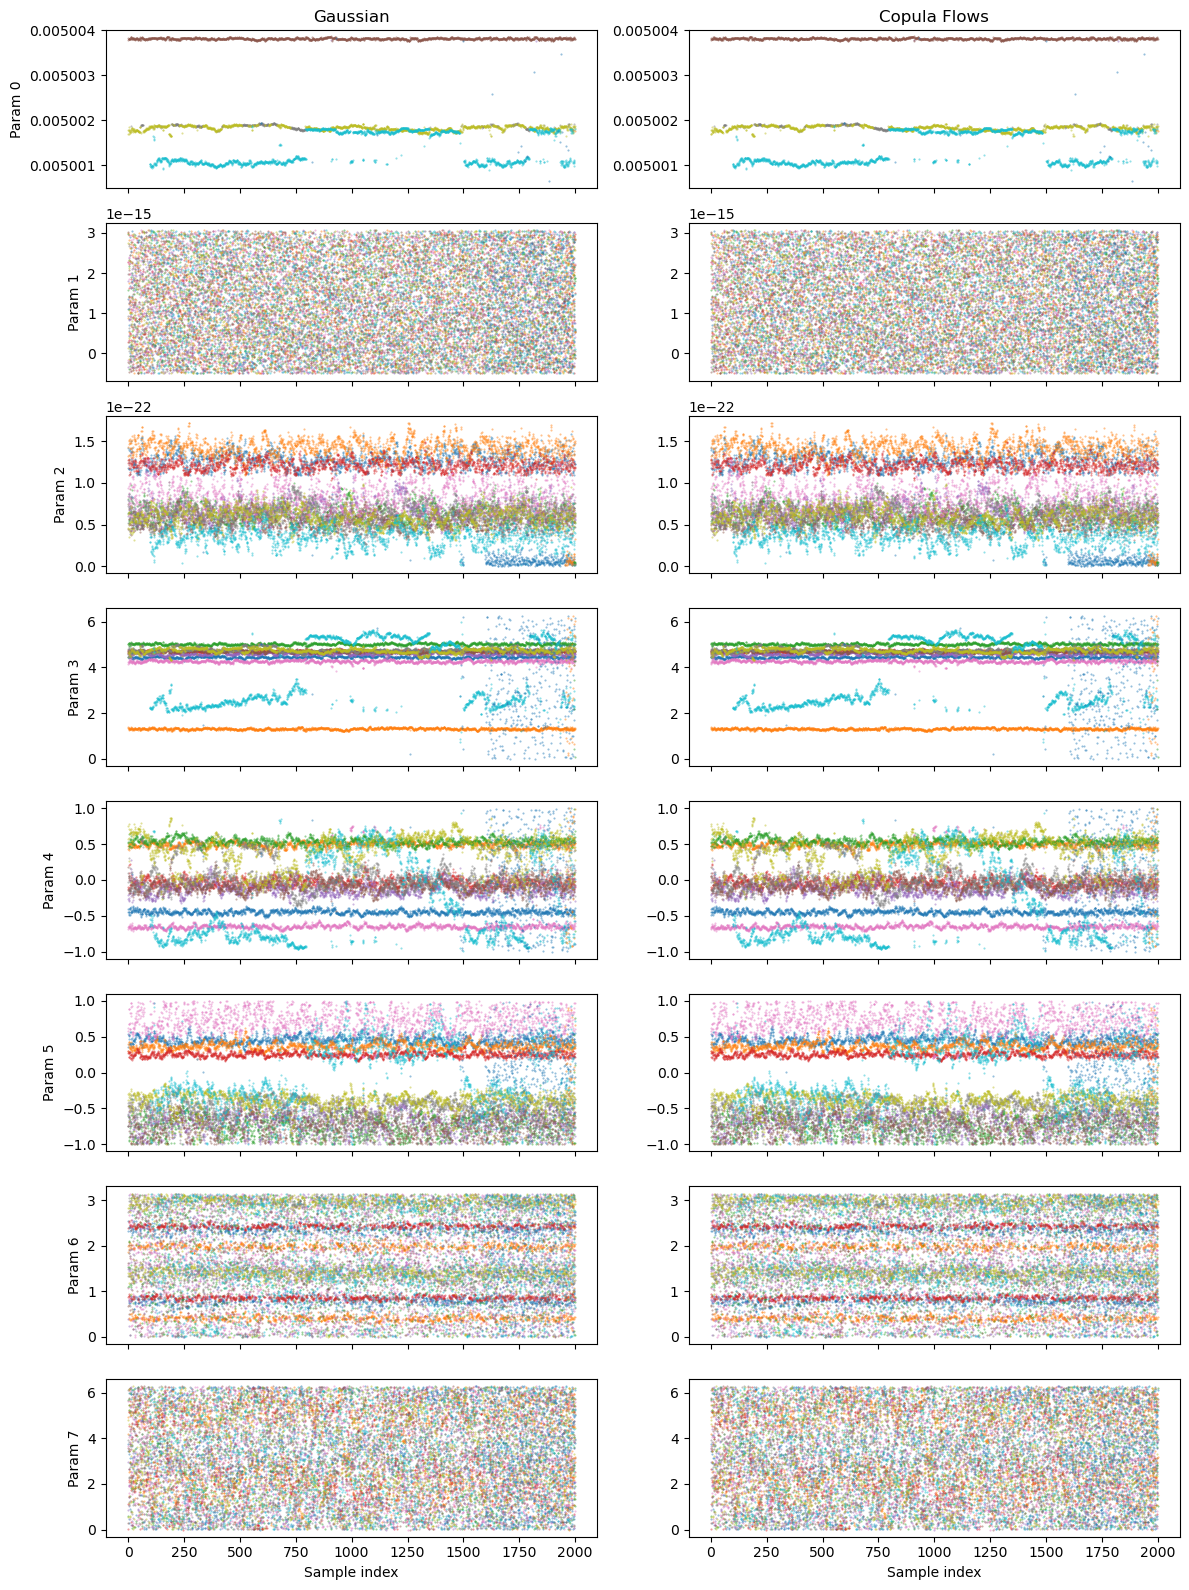

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

# Get chain arrays from the PosteriorChain objects
chain1 = relabeled_chain_nf.chain  # shape: (nsamples, n_sources, n_params)
chain2 = relabeled_chain_nf.chain

nsamples, n_sources, n_params = chain1.shape

fig, axes = plt.subplots(n_params, 2, figsize=(12, 2 * n_params), sharex=True)

for i in range(n_params):
    ax_left = axes[i, 0]
    ax_right = axes[i, 1]

    # Plot all sources for parameter i from relabeled_chain
    for j in range(n_sources):
        ax_left.plot(np.arange(nsamples), chain1[:, j, i], '.', markersize=1, alpha=0.5)
    ax_left.set_ylabel(f'Param {i}')
    if i == 0:
        ax_left.set_title('Gaussian')

    # Plot all sources for parameter i from relabeled_new_chain
    for j in range(n_sources):
        ax_right.plot(np.arange(nsamples), chain2[:, j, i], '.', markersize=1, alpha=0.5)
    if i == 0:
        ax_right.set_title('Copula Flows')

axes[0, 0].set_ylim([0.0050005, 0.005004])
axes[0, 1].set_ylim([0.0050005, 0.005004])

axes[-1, 0].set_xlabel('Sample index')
axes[-1, 1].set_xlabel('Sample index')
plt.tight_layout()
plt.show()

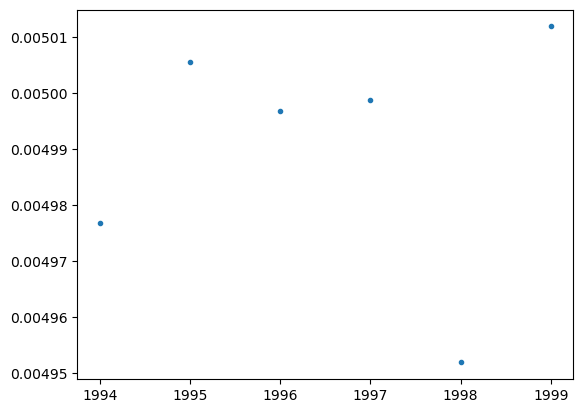

In [28]:
plt.plot(relabeled_chain_nf[:, 12, 0], '.')

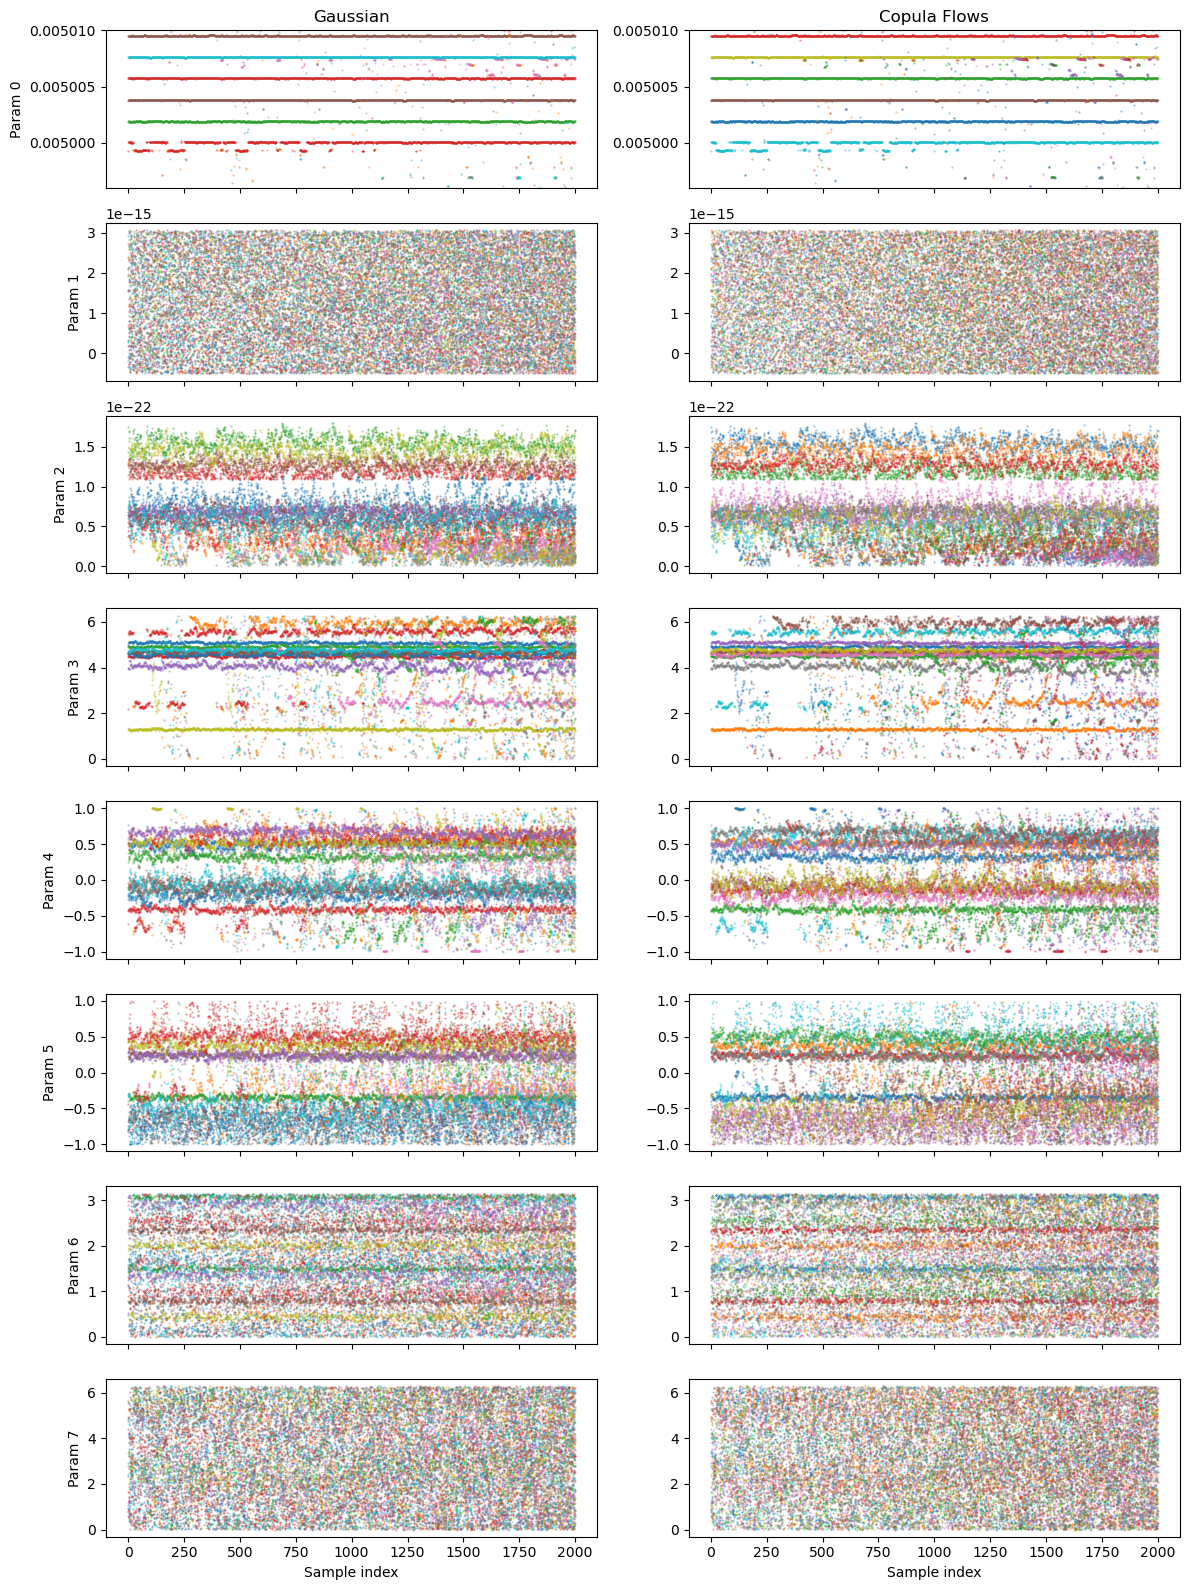

In [20]:
import numpy as np

import matplotlib.pyplot as plt

# Get chain arrays from the PosteriorChain objects
chain1 = relabeled_chain.chain  # shape: (nsamples, n_sources, n_params)
chain2 = relabeled_new_chain.chain

nsamples, n_sources, n_params = chain1.shape

fig, axes = plt.subplots(n_params, 2, figsize=(12, 2 * n_params), sharex=True)

for i in range(n_params):
    ax_left = axes[i, 0]
    ax_right = axes[i, 1]
    
    # Plot all sources for parameter i from relabeled_chain
    for j in range(n_sources):
        ax_left.plot(np.arange(nsamples), chain1[:, j, i], '.', markersize=1, alpha=0.5)
    ax_left.set_ylabel(f'Param {i}')
    if i == 0:
        ax_left.set_title('Gaussian')
    
    # Plot all sources for parameter i from relabeled_new_chain
    for j in range(n_sources):
        ax_right.plot(np.arange(nsamples), chain2[:, j, i], '.', markersize=1, alpha=0.5)
    if i == 0:
        ax_right.set_title('Copula Flows')

axes[0, 0].set_ylim([0.004996, 0.00501])
axes[0, 1].set_ylim([0.004996, 0.00501])
        
axes[-1, 0].set_xlabel('Sample index')
axes[-1, 1].set_xlabel('Sample index')
plt.tight_layout()
plt.show()

In [ ]:
plt.plot(relabeled_new_chain[:, 0, 0])

In [ ]:
achain = relabeled_chain.chain

In [ ]:
single_entry = relabeled_chain[:, 0, :]

In [ ]:
one_entry = achain.reshape(-1, 8)[:, 0]

In [ ]:
a = np.nanmin(one_entry)
b = np.nanmax(one_entry)

In [ ]:
transform0 = Transformed(InverseStandardize(), NormalToUniform)

In [ ]:
transform0 = InverseStandardize(np.nanmean(single_entry), np.nanstd(single_entry))
transform1 = NormalToUniform(a, b)

In [ ]:
def combined_transforms(a, b, mean, std):
    transform0 = NormalToUniform(a, b)
    transform1 = InverseStandardize(mean, std)
    return Transformed(transform0, transform1)

In [ ]:
transform = combined_transforms(a, b, np.nanmean(single_entry), np.nanstd(single_entry))

In [ ]:
transform = InverseStandardizeNormalToUniform(a, b, np.nanmean(single_entry), np.nanstd(single_entry))

In [ ]:
from petra.flows import NormalToUniformInverseStandardize

In [ ]:
transform = NormalToUniformInverseStandardize(a, b, np.nanmean(single_entry), np.nanstd(single_entry), eps=1e-6)

In [ ]:
nonans = single_entry[~np.isnan(single_entry).any(axis=1)]
vals = jax.jit(jax.vmap(transform.inverse_and_log_det))(nonans[:, 0])

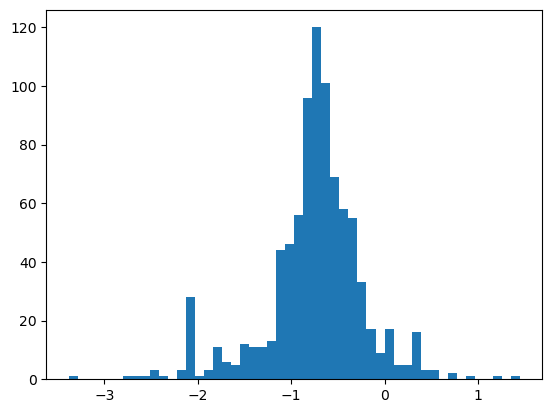

In [ ]:
plt.hist(vals[0], bins=50);

In [ ]:
nonans = single_entry[~np.isnan(single_entry).any(axis=1)]
vals0 = jax.jit(jax.vmap(transform1.inverse_and_log_det))(nonans[:, 0])
vals1 = jax.jit(jax.vmap(transform0.inverse_and_log_det))(vals0[0])
# vals = jax.jit(jax.vmap(transform0.inverse_and_log_det))(nonans[:,0])

In [ ]:
original = jax.jit(jax.vmap(transform.transform_and_log_det))(vals[0])

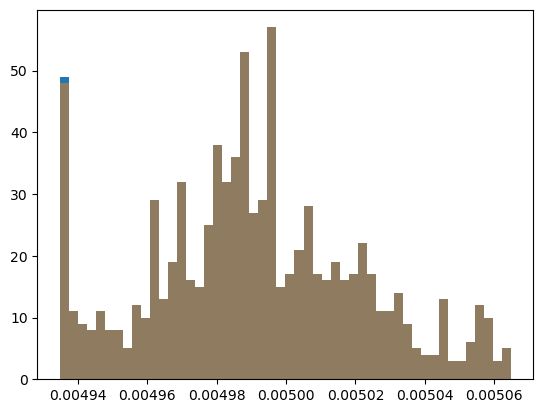

In [ ]:
counts, bins, __ = plt.hist(original[0], bins=50);
plt.hist(nonans[:, 0], bins=bins, alpha=0.5);

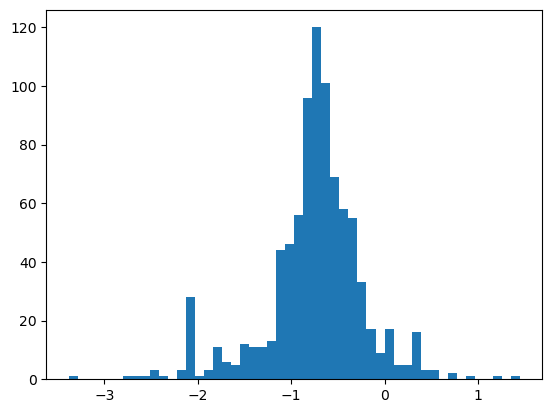

In [ ]:
plt.hist(vals1[0], bins=50);

In [ ]:
vals[0].shape

(870,)

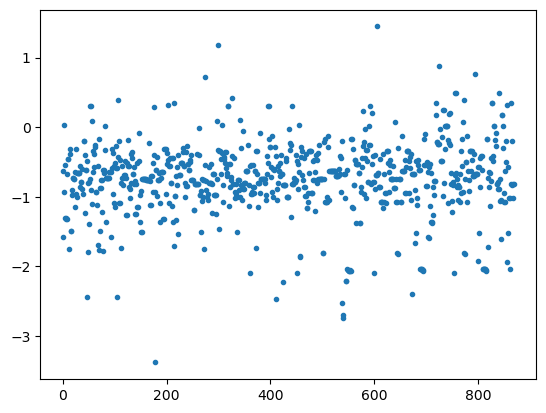

In [ ]:
plt.plot(vals[0], '.')

In [ ]:
uniform_prior = make_uniform_prior(relabeled_chain.chain)

In [ ]:
uniform_prior = jax.jit(jax.vmap(uniform_prior.log_prob))

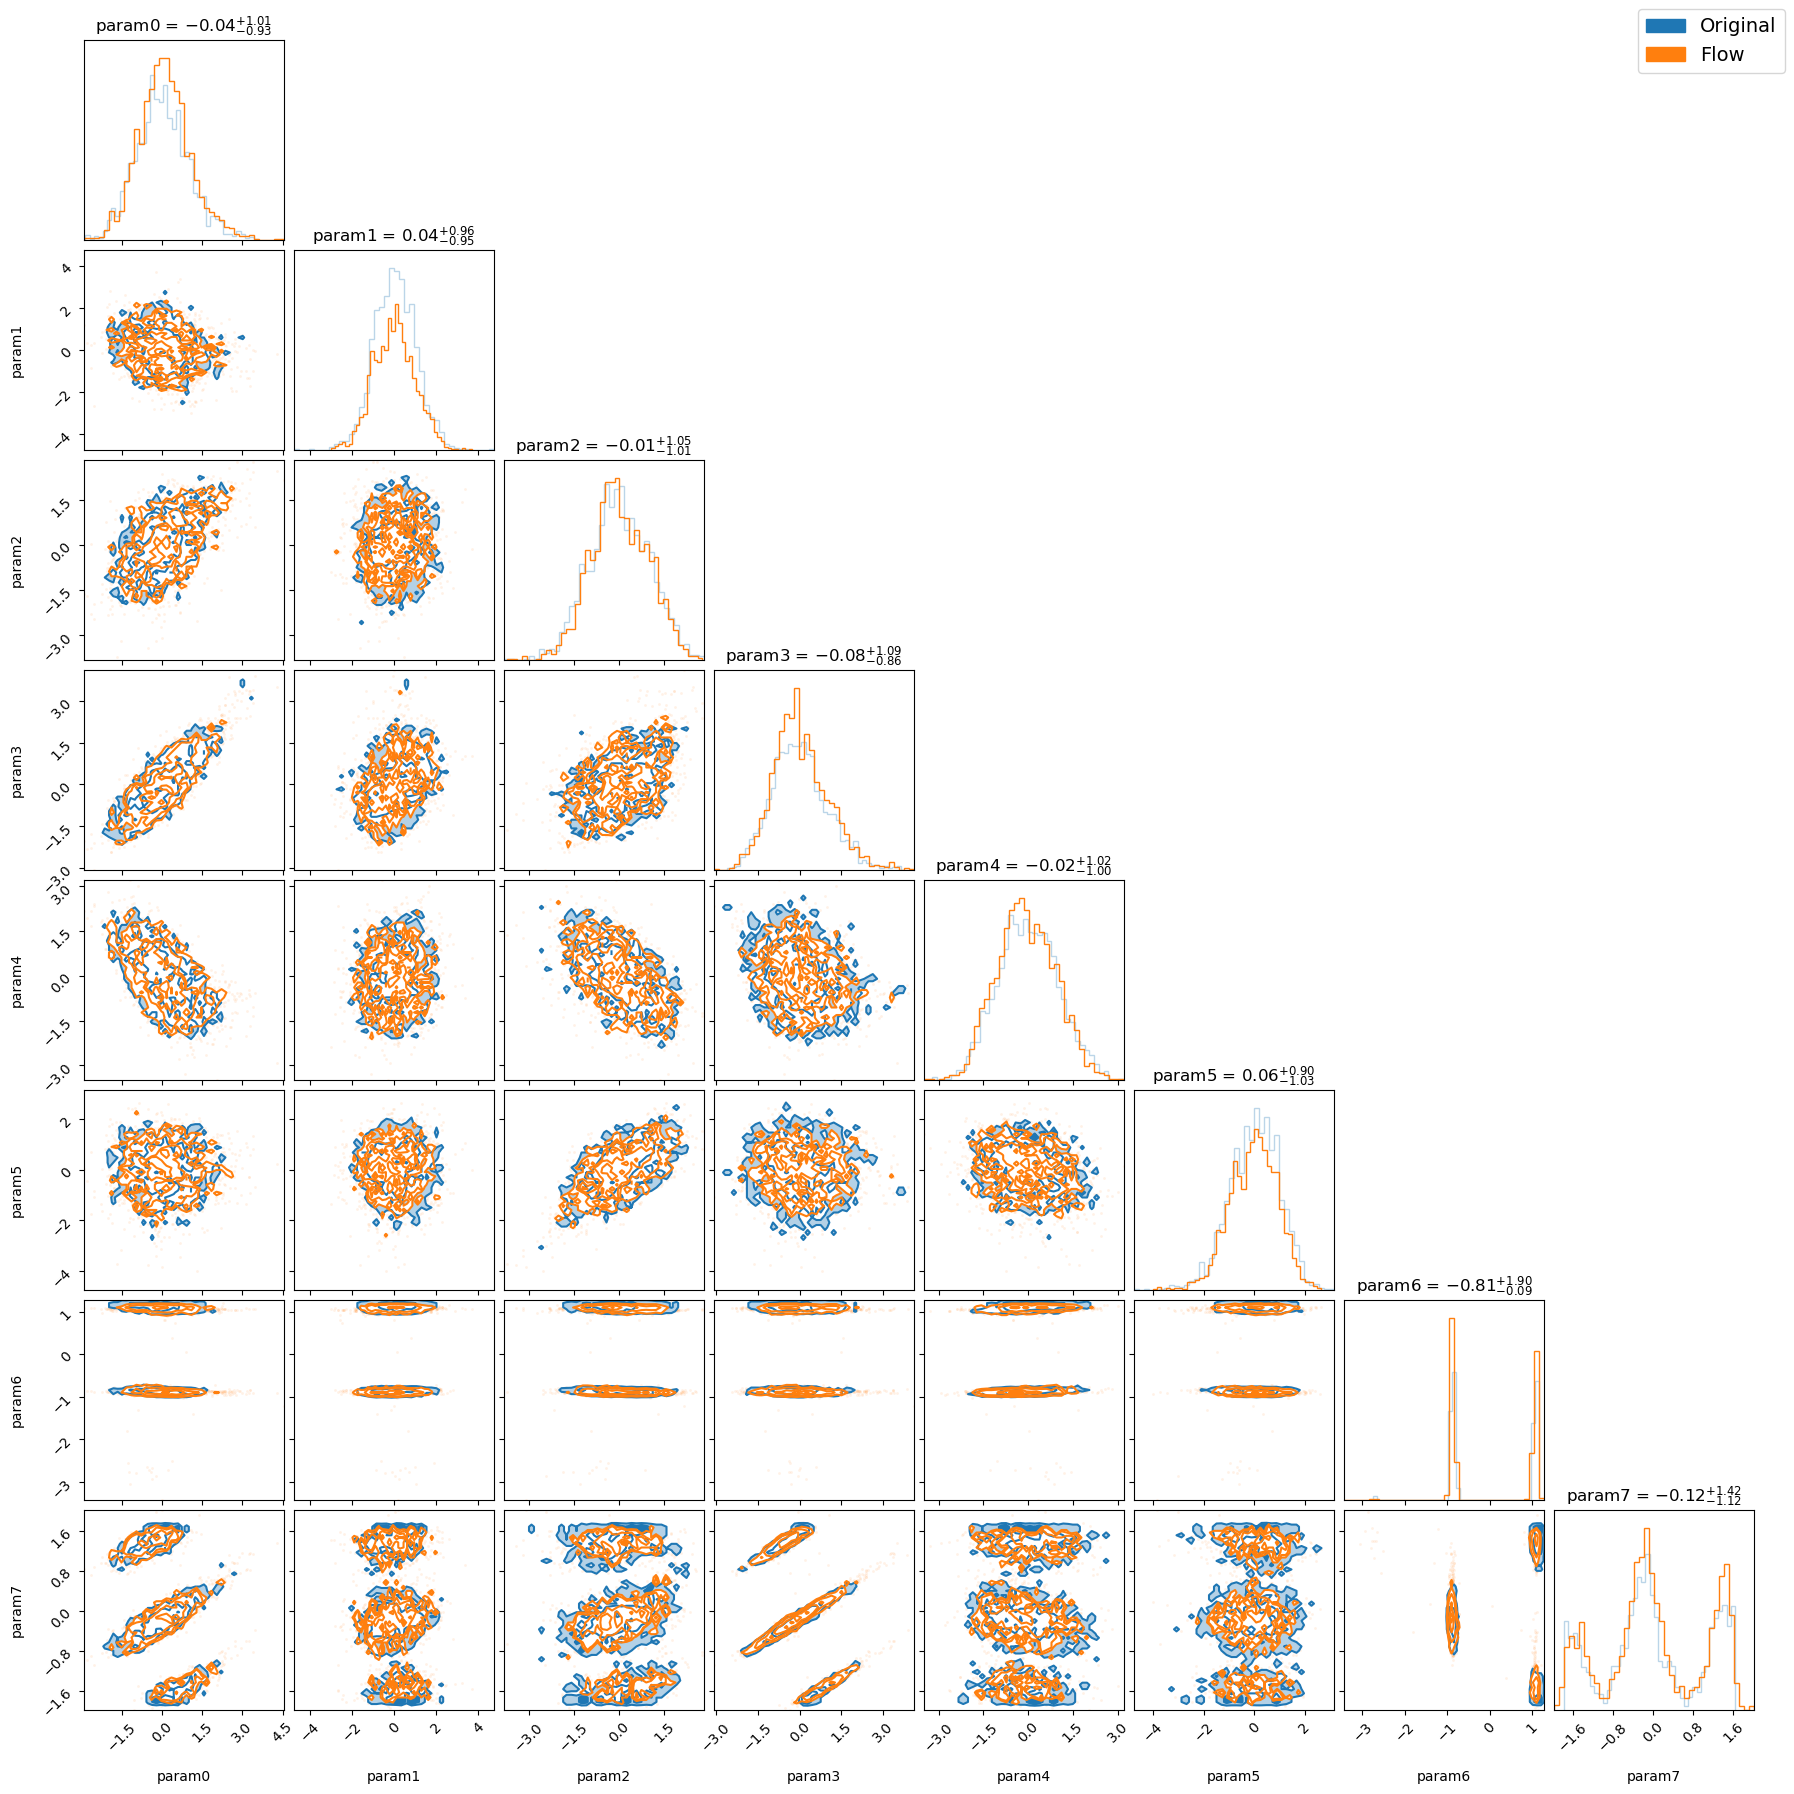

In [ ]:
n_samples = len(x2)
key, subkey = jax.random.split(key)
x_samples = flow.sample(subkey, (n_samples,))

# assume `x` is your original (N, D) array and `x_samples` is the flow samples (M, D)
labels = [f"param{i}" for i in range(x.shape[1])]

shared_bins = 40
ranges = [(float(x2[:, i].min()), float(x2[:, i].max())) for i in range(x.shape[1])]

# 1) Draw the original samples in blue
fig = corner.corner(
    np.array(x2),
    labels=labels,
    color="C0",
    bins=shared_bins,
    plot_datapoints=False,
    fill_contours=True,
    levels=[0.5, 0.9],
    show_titles=True,
    title_fmt=".2f",
    hist_kwargs={"alpha": 0.3},
)

# 2) Overlay the flow samples in red
corner.corner(
    np.array(x_samples),
    fig=fig,
    labels=labels,
    color="C1",
    bins=shared_bins,
    plot_datapoints=True,
    fill_contours=False,
    plot_density=False,
)

# 3) Add a legend
orig_patch = mpatches.Patch(color="C0", label="Original")
flow_patch = mpatches.Patch(color="C1", label="Flow")
fig.legend(handles=[orig_patch, flow_patch], loc="upper right", fontsize=14)

plt.show()

In [ ]:
import jax.numpy as jnp
from jax.scipy.special import erfinv
from jax.scipy.stats import gaussian_kde


x = relabeled_chain.chain[:, 6, 1]
x = x[~np.isnan(x)]  # remove NaNs if any
# 1) fit KDE on your 1D array x of shape (N,)
kde = gaussian_kde(x, bw_method='scott')
# wrap it for JAX
def log_pdf(xi):
    return kde.logpdf(xi)  # pdf→logpdf

# 2) define a u=F̂(x) routine by numeric integral (or approximate with cumsum)
#    here we cheat and use cdf from scipy (not pure JAX), just to illustrate:
def cdf(xi):
    return jnp.array(kde.integrate_box_1d(-jnp.inf, xi))

# 3) your bijector transform_and_log_det
def transform_and_log_det(x_batch, eps=1e-10):
    xs = jnp.sort(x_batch)
    u = jax.vmap(cdf)(xs)            # smooth CDF
    plt.plot(xs, u, 'o', markersize=1, label='CDF')
    plt.show()
    u = jnp.clip(u, eps, 1 - eps)
    z = jnp.sqrt(2.0) * erfinv(2.0*u - 1.0)     # → standard normal
    # Jacobians:
    log_du_dx = log_pdf(x_batch)               # log f̂(x)
    # dz/du = sqrt(2) / sqrt(pi) * exp(erfinv(...)**2)
    log_dz_du = jnp.log(jnp.sqrt(2.0/jnp.pi)) + erfinv(2*u-1)**2
    total_log_det = jnp.sum(log_du_dx + log_dz_du)
    return z, total_log_det

In [ ]:
x.shape

(2000,)

In [ ]:
kde = gaussian_kde(x, bw_method='scott')

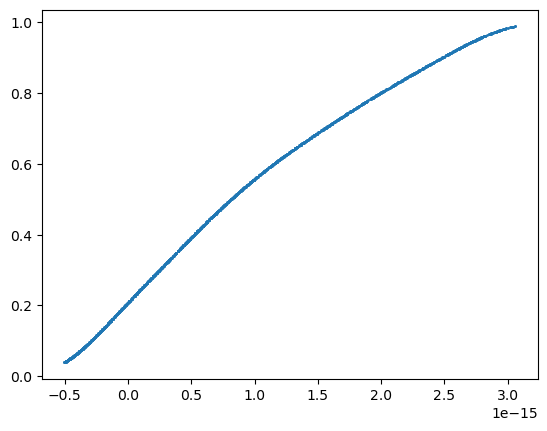

In [ ]:
x_new = transform_and_log_det(x)

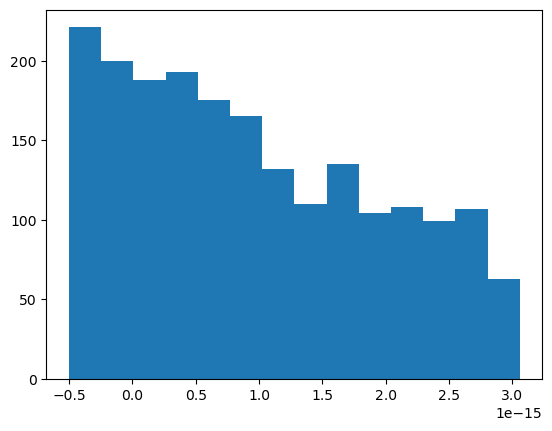

In [ ]:
plt.hist(x, bins='auto');

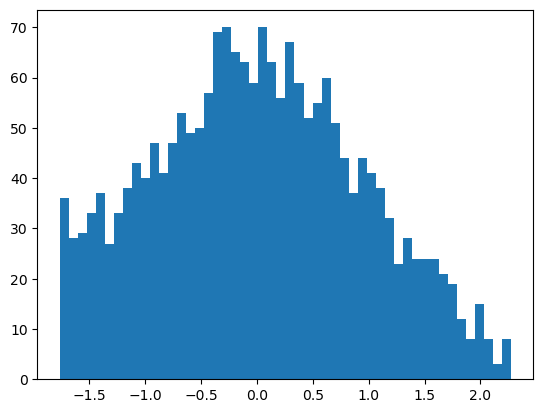

In [ ]:
plt.hist(x_new[0], bins=50);

In [ ]:
transform = bij.Stack([non_trainable(InverseStandardize(np.mean(x[:, i]), np.std(x[:, i]))) if i not in uniform_idxs else non_trainable(NormalToUniform(np.min(x[:, i]), np.max(x[:, i]))) for i in range(x.shape[1])])
dist = Transformed(flow, transform)

In [ ]:
result_x, __ = dist.sample_and_log_prob(subkey, (len(x),))

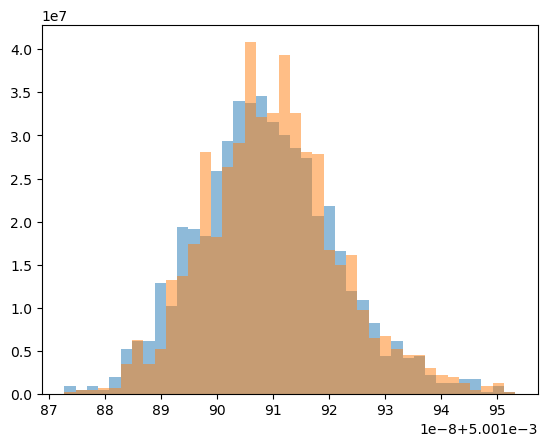

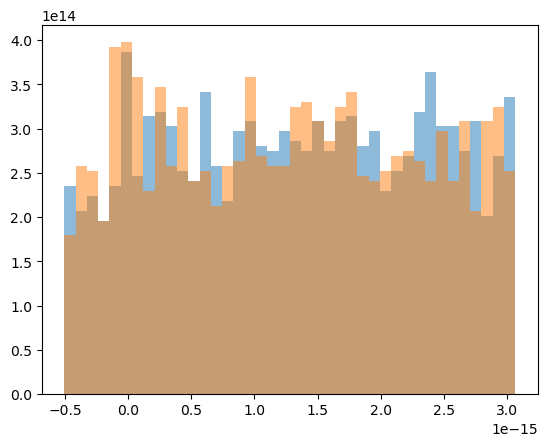

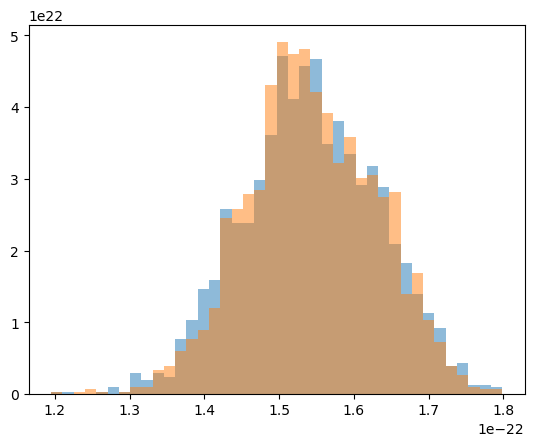

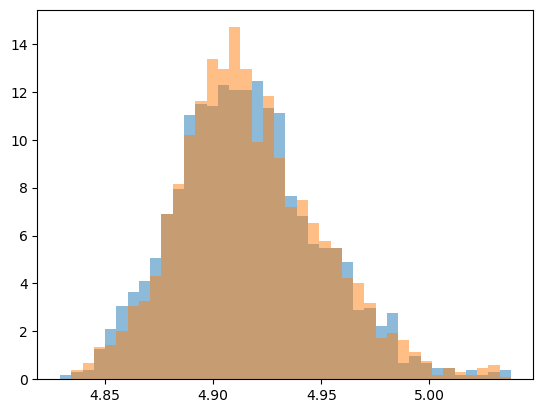

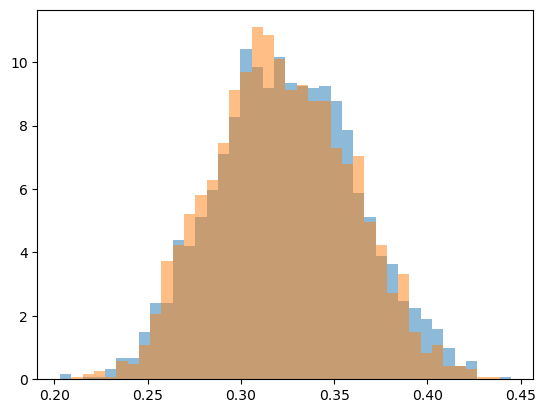

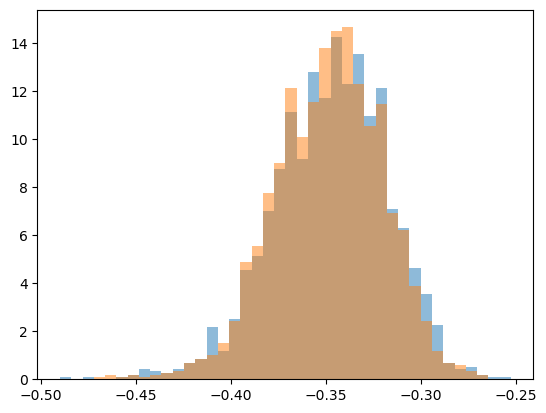

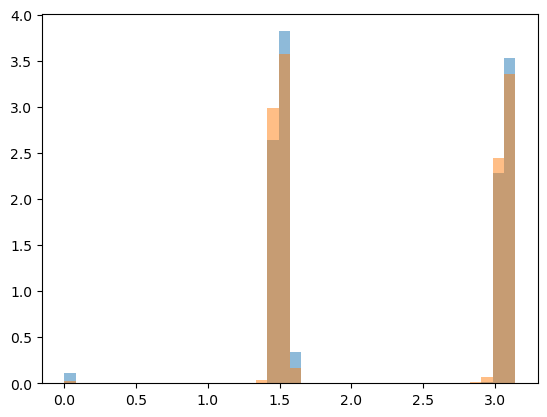

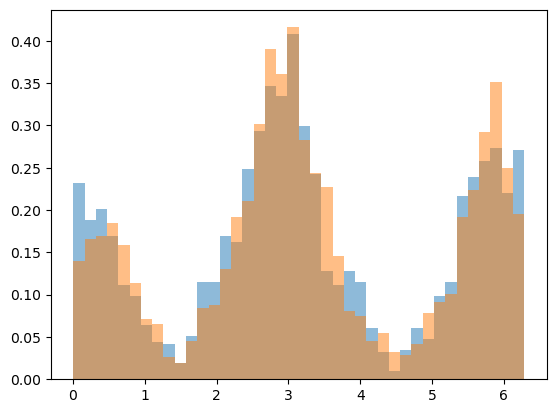

In [ ]:
for i in range(x.shape[1]):
    counts, bins, __ = plt.hist(x[:, i], bins=40, alpha=0.5, label='Original', color='C0', density=True)
    plt.hist(result_x[:, i], bins=bins, alpha=0.5, label='Flow', color='C1', density=True)
    plt.show()

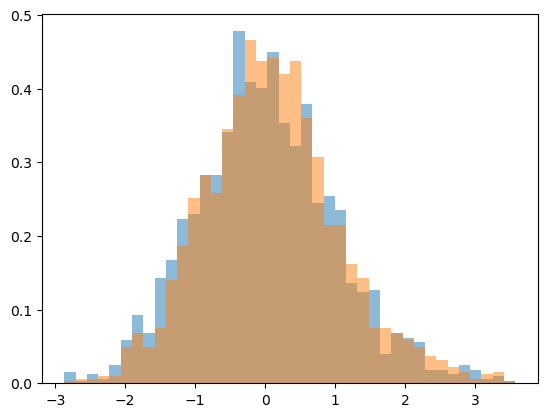

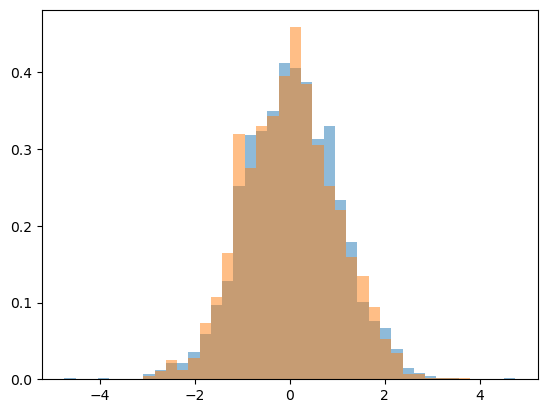

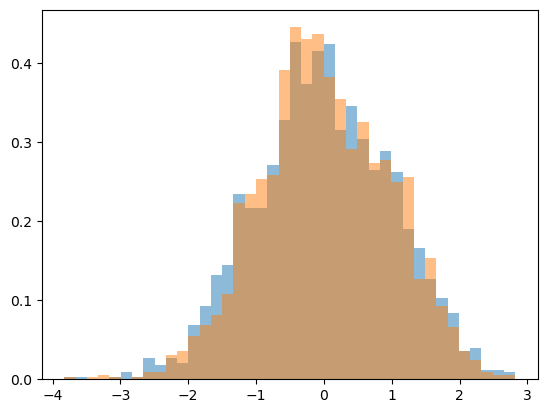

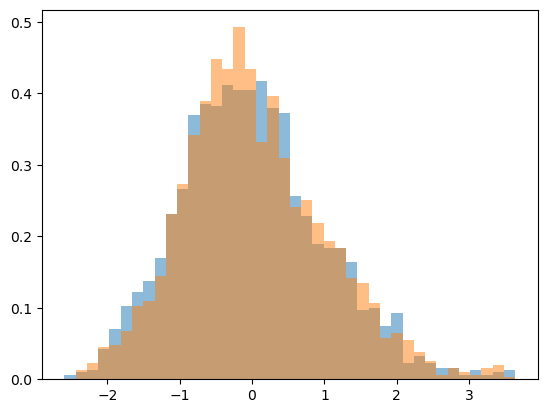

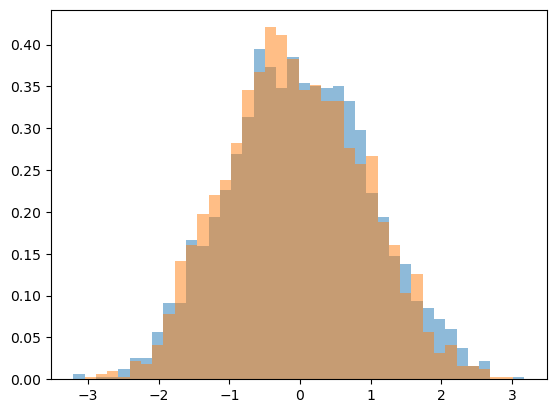

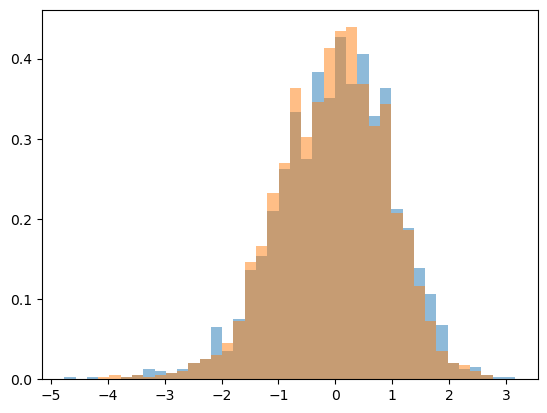

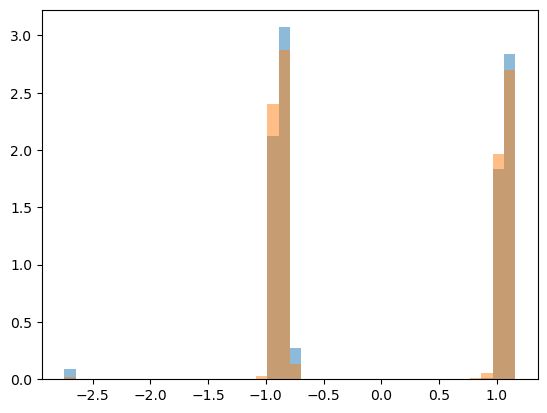

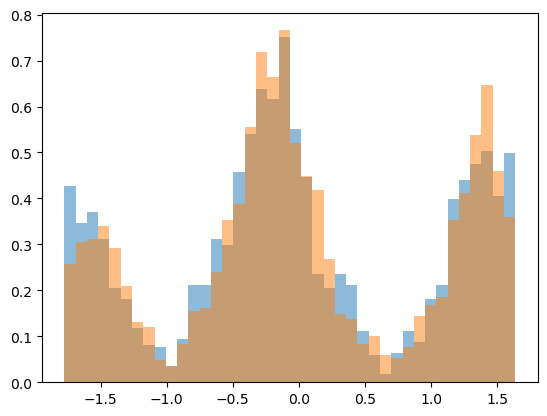

In [ ]:
for i in range(x.shape[1]):
    counts, bins, __ = plt.hist(x2[:, i], bins=40, alpha=0.5, label='Original', color='C0', density=True)
    plt.hist(x_samples[:, i], bins=bins, alpha=0.5, label='Flow', color='C1', density=True)
    plt.show()